In [216]:
import pandas as pd
import numpy as np
import requests
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [217]:

df_raw = pd.read_csv('anime.csv')
df_raw.head(3)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",Unknown,...,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,TV,26,"Apr 1, 1998 to Sep 30, 1998",Spring 1998,...,50229.0,75651.0,86142.0,49432.0,15376.0,5838.0,1965.0,664.0,316.0,533.0


## Clean Data

Key issues:
- `Score` and `Episodes` are stored as strings with `'Unknown'` placeholders — use `errors='coerce'` to safely convert
- `Genres`, `Type`, `Source` need encoding
- `Duration` is a freeform string like `"24 min. per ep."`

**Common bug:** `pd.to_numeric(df['Score'])` crashes on `'Unknown'`. Always pass `errors='coerce'`.

In [218]:
df = df_raw.copy()

# Fix numeric columns stored as strings
df['Score']    = pd.to_numeric(df['Score'],    errors='coerce')
df['Episodes'] = pd.to_numeric(df['Episodes'], errors='coerce')

# Parse duration strings -> total minutes
def parse_duration(s):
    if pd.isna(s) or s == 'Unknown': return np.nan
    s, total = str(s).lower(), 0
    if 'hr'  in s:
        try: total += int(s.split('hr')[0].strip().split()[-1]) * 60
        except: pass
    if 'min' in s:
        try: total += int(s.split('min')[0].strip().split()[-1])
        except: pass
    return total if total > 0 else np.nan

df['Duration_min'] = df['Duration'].apply(parse_duration)

# Replace 'Unknown' strings with NaN
for col in ['Type', 'Source', 'Rating']:
    df[col] = df[col].replace('Unknown', np.nan)

# Drop rows with no Score (our label)
before = len(df)
df = df.dropna(subset=['Score'])
print(f'Dropped {before - len(df):,} rows missing Score → {len(df):,} remaining')
df[['Score','Episodes','Type','Source','Duration_min','Members']].isnull().sum()

Dropped 5,141 rows missing Score → 12,421 remaining


,0
Score,0
Episodes,105
Type,0
Source,1978
Duration_min,272
Members,0


In [219]:
# One-hot encode top genres
TOP_GENRES = [
    'Action','Adventure','Comedy','Drama','Fantasy',
    'Romance','Sci-Fi','Slice of Life','Shounen','Horror',
    'Mystery','Sports','Supernatural','Thriller','Mecha'
]
for g in TOP_GENRES:
    df[f'genre_{g.replace(" ","_")}'] = df['Genres'].str.contains(g, na=False).astype(int)

# One-hot encode Type
df['Type'] = df['Type'].fillna('Unknown')
df = pd.concat([df, pd.get_dummies(df['Type'],   prefix='type')],   axis=1)

# One-hot encode Source (bucket rare values)
TOP_SOURCES = ['Manga','Light novel','Original','Visual novel','Game','Novel']
df['Source_clean'] = df['Source'].apply(lambda x: x if x in TOP_SOURCES else 'Other')
df = pd.concat([df, pd.get_dummies(df['Source_clean'], prefix='source')], axis=1)

# Ordinal encode age rating
rating_map = {
    'G - All Ages':0, 'PG - Children':1,
    'PG-13 - Teens 13 or older':2,
    'R - 17+ (violence & profanity)':3,
    'R+ - Mild Nudity':4, 'Rx - Hentai':5
}
df['Rating_enc'] = df['Rating'].map(rating_map).fillna(2)

# Fill remaining numeric nulls
df['Episodes']    = df['Episodes'].fillna(df['Episodes'].median())
df['Duration_min']= df['Duration_min'].fillna(df['Duration_min'].median())

print('Feature engineering done. Shape:', df.shape)

Feature engineering done. Shape: (12421, 66)


## Define Supervised Learning Problem

**Classification or Regression?** Classification.

The stakeholder needs a yes/no signal: *"Is this anime worth licensing?"* A regression score is harder to act on. We binarize at **7.5** — roughly the top 30% of scored anime — which maps cleanly to a business decision.

**Label:** `high_rated = 1` if `Score >= 7.5`, else `0`.

In [220]:
THRESHOLD = 7.5
df['high_rated'] = (df['Score'] >= THRESHOLD).astype(int)

print(df['high_rated'].value_counts())
print(f"High rated: {df['high_rated'].mean()*100:.1f}%")

high_rated
0    10825
1     1596
Name: count, dtype: int64
High rated: 12.8%


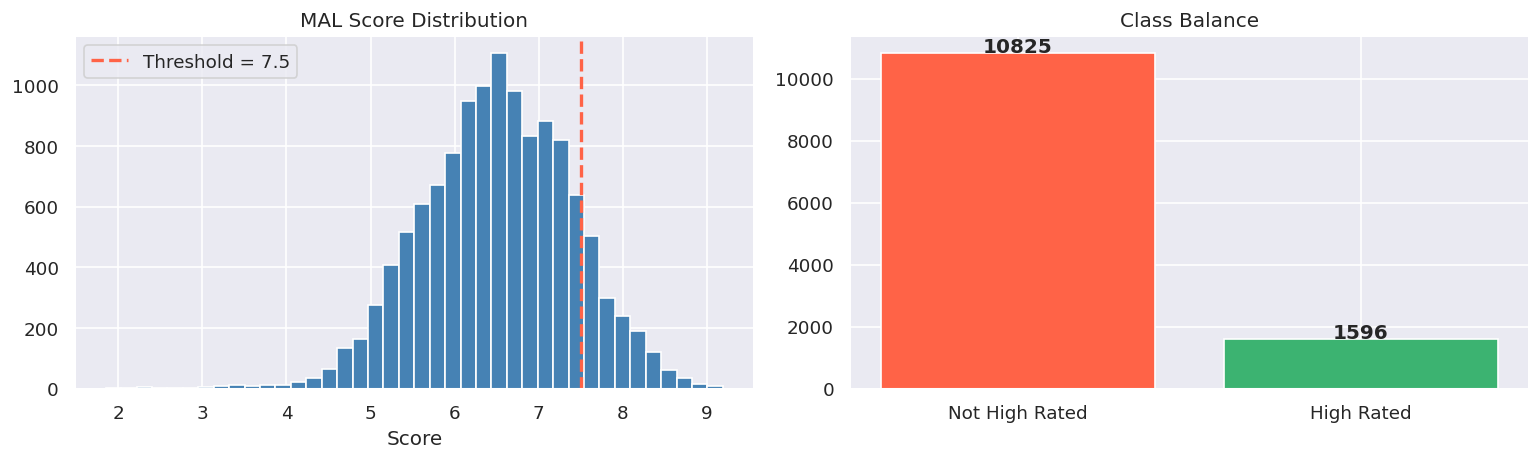

In [221]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Score'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(THRESHOLD, color='tomato', linestyle='--', lw=2, label=f'Threshold = {THRESHOLD}')
axes[0].set_title('MAL Score Distribution')
axes[0].set_xlabel('Score'); axes[0].legend()

counts = df['high_rated'].value_counts()
axes[1].bar(['Not High Rated', 'High Rated'], counts.values, color=['tomato','mediumseagreen'], edgecolor='white')
axes[1].set_title('Class Balance')
for i,v in enumerate(counts.values): axes[1].text(i, v+30, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_score_distribution.png', bbox_inches='tight')
plt.show()

## Define Features

We use features a platform would know **at or before airing** — no post-hoc engagement data leakage.

| Feature | Type | Justification |
|---|---|---|
| `Episodes` | Numeric | Show length correlates with format/budget |
| `Members` | Numeric | Pre-rating hype/visibility proxy |
| `Favorites` | Numeric | Stronger engagement signal |
| `Duration_min` | Numeric | Episode length reflects budget/format |
| `Rating_enc` | Ordinal | Age rating reflects content maturity |
| `genre_*` (15) | Binary | Genre is a known quality predictor |
| `type_*` | Binary | TV vs Movie vs OVA behave differently |
| `source_*` | Binary | Adaptation source vs original |

> Score-N histogram columns are **excluded** — they're derived from the score itself (data leakage).

In [222]:
genre_cols  = [c for c in df.columns if c.startswith('genre_')]
type_cols   = [c for c in df.columns if c.startswith('type_')]
source_cols = [c for c in df.columns if c.startswith('source_')]

FEATURES = ['Episodes','Members','Favorites','Duration_min','Rating_enc'] + genre_cols + type_cols + source_cols
LABEL    = 'high_rated'

X = df[FEATURES]
y = df[LABEL]

print(f'{len(FEATURES)} features, {len(X):,} samples')

33 features, 12,421 samples


## Split Data into Training / Testing

In [223]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test  positive rate: {y_test.mean():.3f}')

Train: 9,936  |  Test: 2,485
Train positive rate: 0.129
Test  positive rate: 0.128


## Train Models

**Decision Tree** — interpretable, visualizable, no scaling needed. `max_depth=5` to avoid overfitting.

In [224]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=99)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt, target_names=['Not High Rated','High Rated']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.4f}')

cv_dt = cross_val_score(dt, X, y, cv=5, scoring='f1')
print(f'5-fold CV F1: {cv_dt.mean():.4f} ± {cv_dt.std():.4f}')

=== Decision Tree ===
                precision    recall  f1-score   support

Not High Rated       0.93      0.98      0.95      2166
    High Rated       0.75      0.50      0.60       319

      accuracy                           0.91      2485
     macro avg       0.84      0.74      0.77      2485
  weighted avg       0.91      0.91      0.91      2485

ROC-AUC: 0.9289
5-fold CV F1: 0.5616 ± 0.0692


## Evaluate Model

In [225]:
# Summary table
results = pd.DataFrame({
    'Model':     ['Decision Tree'],
    'Accuracy':  [accuracy_score(y_test, y_pred_dt)],
    'Precision': [precision_score(y_test, y_pred_dt)],
    'Recall':    [recall_score(y_test, y_pred_dt)],
    'F1':        [f1_score(y_test, y_pred_dt)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_dt)],
}).set_index('Model').round(4)

results

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Decision Tree,0.9143,0.7524,0.4953,0.5974,0.9289


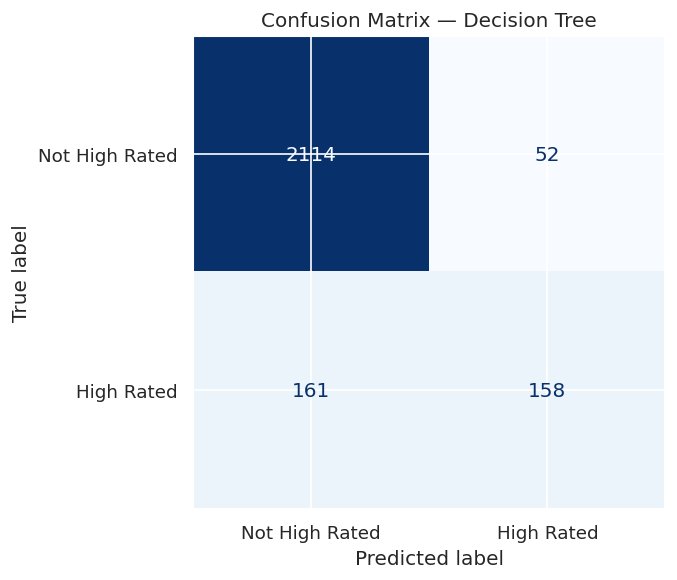

In [226]:
# Confusion matrices
fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt),
                       display_labels=['Not High Rated','High Rated']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Decision Tree')
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight')
plt.show()

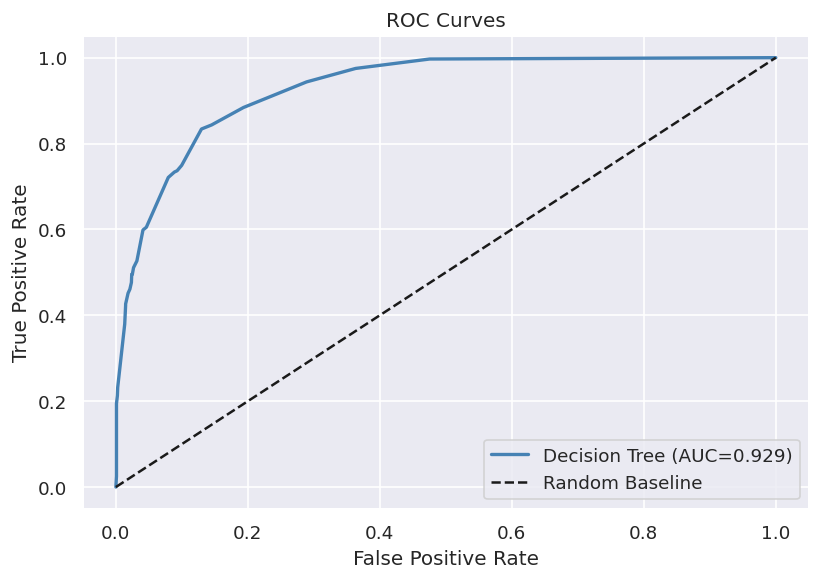

In [227]:
import matplotlib.pyplot as plt
import seaborn as sns

# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
for y_prob, label, color in [(y_prob_dt,'Decision Tree','steelblue')]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC={roc_auc_score(y_test, y_prob):.3f})', color=color, lw=2)
ax.plot([0,1],[0,1],'k--',lw=1.5,label='Random Baseline')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curves')
ax.legend(); plt.tight_layout()
plt.savefig('fig_roc_curves.png', bbox_inches='tight')
plt.show()

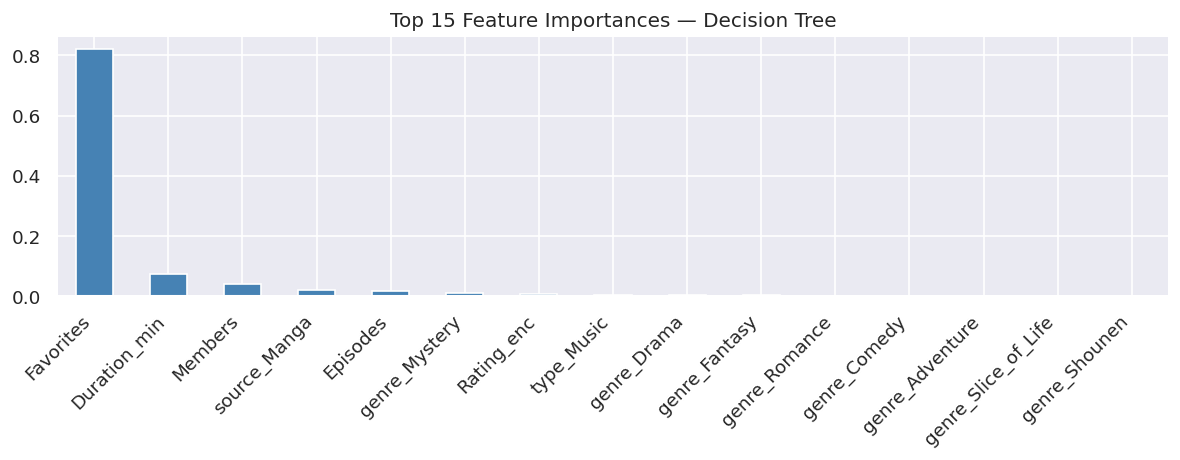

In [228]:
# Feature importance (Decision Tree)
importances = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 4))
importances.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Decision Tree')
ax.set_xticklabels(importances.index, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

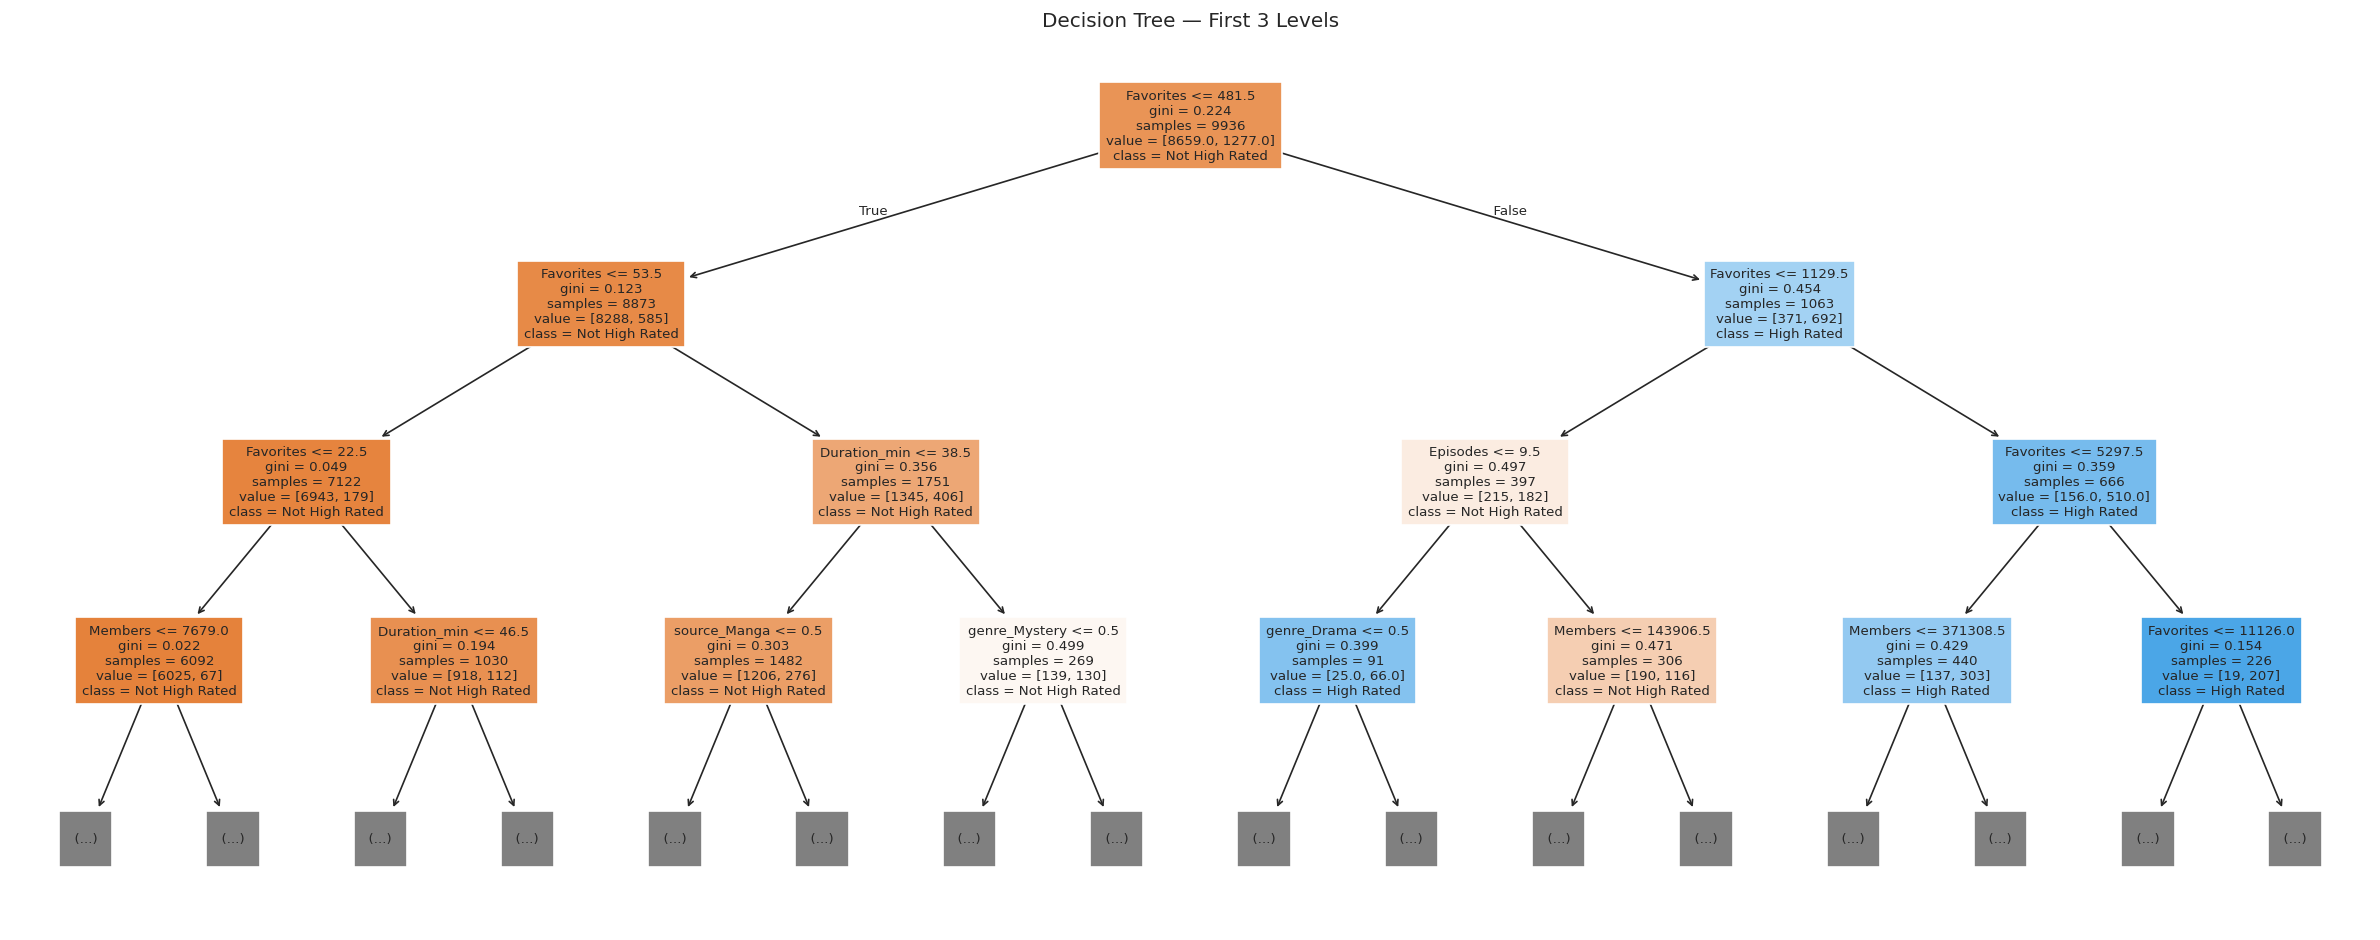

In [229]:
# Decision tree visualization (first 3 levels)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=FEATURES, class_names=['Not High Rated','High Rated'],
          filled=True, max_depth=3, ax=ax, fontsize=8)
plt.title('Decision Tree — First 3 Levels')
plt.tight_layout()
plt.savefig('fig_decision_tree.png', bbox_inches='tight', dpi=150)
plt.show()

## 5 Samples the Model Got Wrong

Using the Decision Tree as our primary model.

In [230]:
test_df = df.loc[X_test.index].copy()
test_df['predicted'] = y_pred_dt
test_df['actual']    = y_test.values
test_df['pred_prob'] = y_prob_dt

fp = test_df[(test_df['predicted'] == 1) & (test_df['actual'] == 0)]  # predicted hit, wasn't
fn = test_df[(test_df['predicted'] == 0) & (test_df['actual'] == 1)]  # predicted flop, was hit

print(f'False Positives: {len(fp)}  |  False Negatives: {len(fn)}')

False Positives: 52  |  False Negatives: 161


In [231]:
COLS = ['Name','Score','Type','Source','Genres','Episodes','Members','predicted','actual','pred_prob']

# 3 most confident false negatives + 2 most confident false positives
wrong_5 = pd.concat([
    fn.nsmallest(3, 'pred_prob')[COLS],
    fp.nlargest(2,  'pred_prob')[COLS]
])
wrong_5

,Name,Score,Type,Source,Genres,Episodes,Members,predicted,actual,pred_prob
14591,Neo-Aspect,7.51,Music,Original,Music,1.0,2005,0,1,0.000924
16905,Wu Dong Qian Kun 2nd Season,7.60,ONA,Novel,"Action, Adventure, Historical, Romance, Martia...",12.0,1518,0,1,0.019108
5693,Heartcatch Precure! Movie: Hana no Miyako de F...,7.59,Movie,Original,"Fantasy, Kids, Magic, Shoujo",1.0,5729,0,1,0.019108
21,Neon Genesis Evangelion: Death & Rebirth,7.45,Movie,Original,"Drama, Mecha, Psychological, Sci-Fi",1.0,180681,1,0,1.000000
4887,Black★Rock Shooter (OVA),7.12,OVA,Other,"Action, Slice of Life, Drama, School",1.0,161876,1,0,1.000000


In [232]:
for _, row in wrong_5.iterrows():
    err = 'FALSE NEGATIVE (predicted flop, was hit)' if row['predicted']==0 else 'FALSE POSITIVE (predicted hit, was flop)'
    print(f'[{err}]')
    print(f'  Name:     {row["Name"]}')
    print(f'  Score:    {row["Score"]} | Predicted: {"High Rated" if row["predicted"]==1 else "Not High Rated"}')
    print(f'  Type:     {row["Type"]} | Source: {row["Source"]}')
    print(f'  Genres:   {str(row["Genres"])[:80]}')
    print(f'  Episodes: {row["Episodes"]} | Members: {int(row["Members"]):,}')
    print(f'  Pred Prob:{row["pred_prob"]:.3f}\n')

[FALSE NEGATIVE (predicted flop, was hit)]
  Name:     Neo-Aspect
  Score:    7.51 | Predicted: Not High Rated
  Type:     Music | Source: Original
  Genres:   Music
  Episodes: 1.0 | Members: 2,005
  Pred Prob:0.001

[FALSE NEGATIVE (predicted flop, was hit)]
  Name:     Wu Dong Qian Kun 2nd Season
  Score:    7.6 | Predicted: Not High Rated
  Type:     ONA | Source: Novel
  Genres:   Action, Adventure, Historical, Romance, Martial Arts, Fantasy
  Episodes: 12.0 | Members: 1,518
  Pred Prob:0.019

[FALSE NEGATIVE (predicted flop, was hit)]
  Name:     Heartcatch Precure! Movie: Hana no Miyako de Fashion Show... Desu ka!?
  Score:    7.59 | Predicted: Not High Rated
  Type:     Movie | Source: Original
  Genres:   Fantasy, Kids, Magic, Shoujo
  Episodes: 1.0 | Members: 5,729
  Pred Prob:0.019

[FALSE POSITIVE (predicted hit, was flop)]
  Name:     Neon Genesis Evangelion: Death & Rebirth
  Score:    7.45 | Predicted: High Rated
  Type:     Movie | Source: Original
  Genres:   Drama, Me

**False Negatives** — typically niche masterpieces with low member counts. The model over-weights `Members` as a quality proxy, so critically acclaimed but obscure titles look like duds on paper.

**False Positives** — typically popular but mediocre anime. High `Members` + recognizable genres fool the model into predicting a hit, but popularity ≠ critical score. Long-running Shounen with filler are the classic example.

**Core weakness:** `Members` is simultaneously the model's strongest signal and its biggest blind spot — it can't distinguish beloved-niche from popular-mediocre.

## Genre & Source Analysis

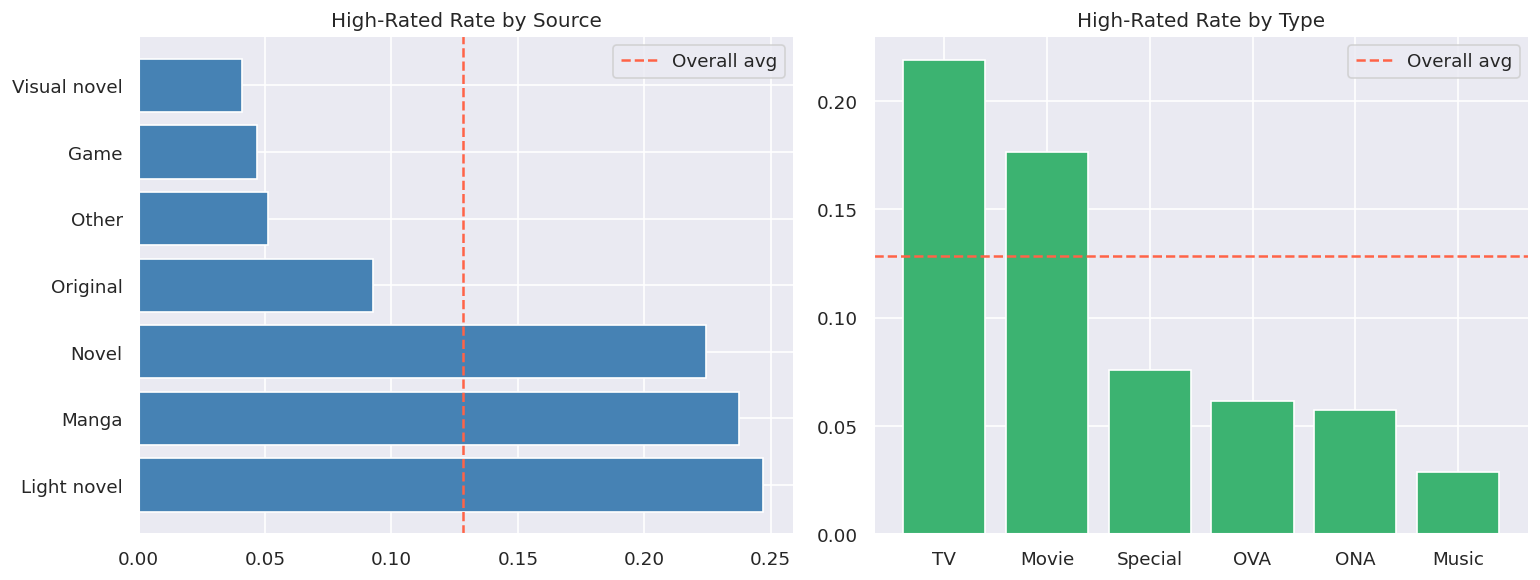

In [233]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# High-rated rate by source
src = df.groupby('Source_clean')['high_rated'].agg(['mean','count']).reset_index()
src = src[src['count'] >= 20].sort_values('mean', ascending=False)
axes[0].barh(src['Source_clean'], src['mean'], color='steelblue', edgecolor='white')
axes[0].axvline(df['high_rated'].mean(), color='tomato', linestyle='--', label='Overall avg')
axes[0].set_title('High-Rated Rate by Source'); axes[0].legend()

# High-rated rate by type
typ = df.groupby('Type')['high_rated'].agg(['mean','count']).reset_index()
typ = typ[typ['count'] >= 20].sort_values('mean', ascending=False)
axes[1].bar(typ['Type'], typ['mean'], color='mediumseagreen', edgecolor='white')
axes[1].axhline(df['high_rated'].mean(), color='tomato', linestyle='--', label='Overall avg')
axes[1].set_title('High-Rated Rate by Type'); axes[1].legend()

plt.tight_layout()
plt.savefig('fig_source_type.png', bbox_inches='tight')
plt.show()

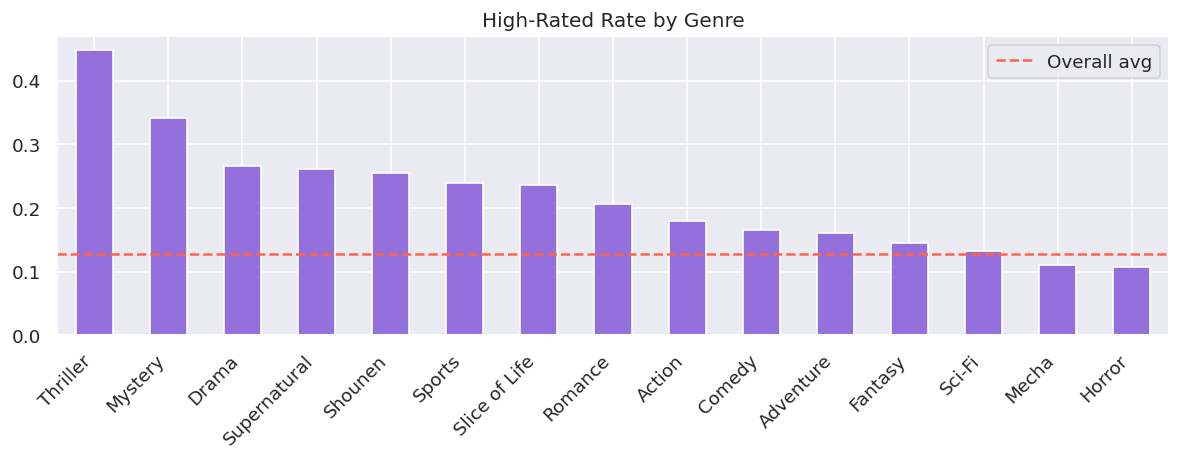

In [234]:
genre_rates = {
    g: df[df[f'genre_{g.replace(" ","_")}'] == 1]['high_rated'].mean()
    for g in TOP_GENRES
    if len(df[df[f'genre_{g.replace(" ","_")}'] == 1]) >= 20
}
genre_series = pd.Series(genre_rates).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
genre_series.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.axhline(df['high_rated'].mean(), color='tomato', linestyle='--', label=f'Overall avg')
ax.set_title('High-Rated Rate by Genre'); ax.set_xticklabels(genre_series.index, rotation=45, ha='right')
ax.legend(); plt.tight_layout()
plt.savefig('fig_genre_rates.png', bbox_inches='tight')
plt.show()